# Test NOTEARS NL & DAGMA NL (default params)

Run the nonlinear variants of NOTEARS and DAGMA with all default hyperparameters on the CBN Exponential + ClaytonCopula dataset.

In [1]:
import sys; sys.path.insert(0, "..")
%load_ext autoreload
%autoreload 2

import time
import numpy as np
import pyagrum as gum
import pyagrum.lib.bn_vs_bn as bn_vs_bn
import torch
from notears.nonlinear import NotearsSobolev, notears_nonlinear
from notears.trace_expm import trace_expm
from notears.utils import is_dag

from pipeline.Benchmark import Benchmark
from pipeline.Structure import Structure
from algorithms import ALL_ALGORITHMS


# Monkey-patch upstream bug: NotearsSobolev.h_func uses bare `d` instead of `self.d`.
def _sobolev_h_func(self):
    fc1_weight = self.fc1_pos.weight - self.fc1_neg.weight
    fc1_weight = fc1_weight.view(self.d, self.d, self.k)
    A = torch.sum(fc1_weight * fc1_weight, dim=2).t()
    return trace_expm(A) - self.d
NotearsSobolev.h_func = _sobolev_h_func


def _full_roundtrip_ok(W, feature_names, golden_structure):
    """Verify W survives the full metric chain: BN -> CPDAG -> Meek -> BN -> EG,
    both on the CPDAG and on its skeleton (mirrors SHDMetric usage)."""
    d = W.shape[0]
    try:
        bn = gum.BayesNet()
        for name in feature_names:
            bn.add(gum.LabelizedVariable(name, name, 2))
        for i in range(d):
            for j in range(d):
                if W[i, j] != 0:
                    bn.addArc(feature_names[i], feature_names[j])
        cpdag = gum.EssentialGraph(bn).pdag()
        structure = Structure(cpdag)

        # Full metric round-trip (CPDAG side)
        dag = gum.MeekRules().propagateToDAG(cpdag)
        bn2 = gum.BayesNet()
        for node_id in dag.nodes():
            n = f"X{node_id}"
            bn2.add(gum.LabelizedVariable(n, n, 2))
        for a in dag.arcs():
            bn2.addArc(f"X{a[0]}", f"X{a[1]}")
        bn_vs_bn.GraphicalBNComparator(bn2, bn2).hamming()

        # Full metric round-trip (skeleton side)
        skel = structure.skeleton().cpdag
        dag_skel = gum.MeekRules().propagateToDAG(skel)
        bn3 = gum.BayesNet()
        for node_id in dag_skel.nodes():
            n = f"X{node_id}"
            bn3.add(gum.LabelizedVariable(n, n, 2))
        for a in dag_skel.arcs():
            bn3.addArc(f"X{a[0]}", f"X{a[1]}")
        bn_vs_bn.GraphicalBNComparator(bn3, bn3).hamming()

        return structure
    except gum.GraphError:
        return None


def _threshold_until_safe(W, feature_names, golden_structure, start):
    """Raise threshold until the structure survives the full metric chain."""
    candidates = [start] + sorted(
        float(m) for m in np.unique(np.abs(W[np.abs(W) > 0])) if m >= start
    )
    seen = set()
    for t in candidates:
        if t in seen:
            continue
        seen.add(t)
        W_t = W.copy()
        W_t[np.abs(W_t) < t] = 0
        if not is_dag(W_t):
            continue
        s = _full_roundtrip_ok(W_t, feature_names, golden_structure)
        if s is not None:
            return s, t
    return None, float("inf")


def learn_sobolev_structure(dataset, golden_structure,
                            k=10, lambda1=0.01, lambda2=0.01,
                            w_threshold=0.3):
    """NOTEARS Sobolev: sinusoidal basis expansion, no hidden NN layers."""
    torch.set_default_dtype(torch.double)
    torch.manual_seed(42)
    X = dataset.data
    d = X.shape[1]
    model = NotearsSobolev(d=d, k=k)
    W_est = notears_nonlinear(model, X, lambda1=lambda1, lambda2=lambda2,
                              w_threshold=0.0)
    structure, eff_t = _threshold_until_safe(
        W_est, dataset.feature_names, golden_structure, w_threshold
    )
    if structure is None:
        print(f"  [sobolev] no threshold survives pyAgrum round-trip; returning empty graph.")
        bn = gum.BayesNet()
        for name in dataset.feature_names:
            bn.add(gum.LabelizedVariable(name, name, 2))
        return Structure(gum.EssentialGraph(bn).pdag())
    if eff_t > w_threshold:
        print(f"  [sobolev] bumped w_threshold {w_threshold} -> {eff_t:.4f} to survive metric chain")
    return structure

/home/mathis/Documents/Travail/cbnsl_benchmark/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def dag_10vars():
    dag = gum.DAG()
    dag.addNodes(10)
    for t, h in [
        (1, 0), (0, 2), (2, 3), (3, 4), (3, 5), (4, 5), (4, 6), (5, 7),
        (6, 7), (6, 8), (7, 8), (9, 8), (2, 9), (9, 7),
    ]:
        dag.addArc(t, h)
    return dag

bench = Benchmark.synthetic_cbn(
    dag=dag_10vars(),
    n_samples=2000,
    marginal_type="Exponential",
    lcc_types="ClaytonCopula",
)
bench

Benchmark(dataset='cbn_Exponential_ClaytonCopula__10vars_2000s', ready)

In [3]:
# Run NOTEARS NL, DAGMA NL and NOTEARS Sobolev with all default params.
# DAGMA NL gets verbose=True so it prints its loss periodically.
# Neither NOTEARS variant exposes a native progress hook in upstream.
ALGOS = [
    #("NOTEARS NL",      "adapter", {}),
    #("DAGMA NL",        "adapter", {"verbose": True}),
    ("NOTEARS Sobolev", "sobolev", {}),
]

timings = {}
structures = {}
for i, (name, kind, params) in enumerate(ALGOS, start=1):
    print(f"[{i}/{len(ALGOS)}] {name}...")
    t0 = time.perf_counter()
    if kind == "adapter":
        algo_cls, default_fixed, _ = ALL_ALGORITHMS[name]
        algo = algo_cls(**{**default_fixed, **params})
        structures[name] = algo.learn_structure(bench.dataset)
    else:  # sobolev
        structures[name] = learn_sobolev_structure(
            bench.dataset, bench.golden_structure, **params
        )
    dt = time.perf_counter() - t0
    timings[name] = dt
    print(f"[{i}/{len(ALGOS)}] {name} done in {dt:.2f}s")

print("\nTimings:")
for name, dt in timings.items():
    print(f"  {name}: {dt:.2f}s")

[1/1] NOTEARS Sobolev...
  [sobolev] bumped w_threshold 0.3 -> 0.3678 to survive metric chain
[1/1] NOTEARS Sobolev done in 76.88s

Timings:
  NOTEARS Sobolev: 76.88s


In [4]:
# Inject results into the Benchmark so we can reuse its plotting helpers.
bench._gs = None
bench._selection_cpdag = None
bench._selection_skeleton = None
bench._structures = structures
bench._scores_cpdag = {}
bench._scores_skeleton = {}
bench._params_cpdag = {name: p for name, _, p in ALGOS}
bench._params_skeleton = {name: p for name, _, p in ALGOS}
for name, s in structures.items():
    bench._scores_cpdag[name] = {
        m.name(): m.compute(ref=bench.golden_structure, test=s)
        for m in bench.metrics
    }
    bench._scores_skeleton[name] = {
        m.name(): m.compute(ref=bench.golden_structure.skeleton(), test=s.skeleton())
        for m in bench.metrics
    }

## Golden structure

Golden CPDAG: 6 arcs, 8 edges


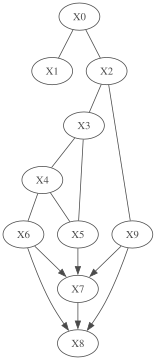

In [5]:
bench.show_golden()

## Scores (CPDAG)

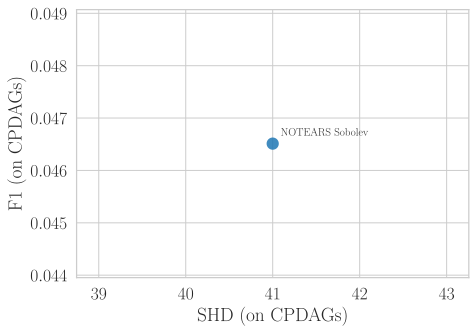

In [6]:
bench.plot_best_scores("cpdag")

## Scores (Skeleton)

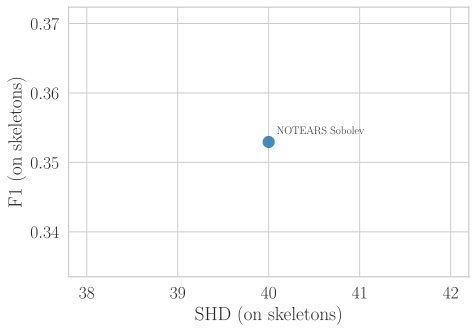

In [7]:
bench.plot_best_scores("skeleton")

## Learned structures

In [8]:
bench.plot_structures()